In [ ]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("wenruliu/adult-income-dataset")

csv_path = os.path.join(path, "adult.csv")
data = pd.read_csv(csv_path)

data.head()

Using Colab cache for faster access to the 'adult-income-dataset' dataset.


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
data = pd.read_csv(csv_path, na_values='?', skipinitialspace=True)
data.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
data.shape

(48842, 15)

In [ ]:
data.dtypes

,0
age,int64
workclass,object
fnlwgt,int64
education,object
educational-num,int64
marital-status,object
occupation,object
relationship,object
race,object
gender,object


In [ ]:
data.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
missing = data.isnull().sum()
missing_percent = (missing / len(data)) * 100
missing_summary = pd.DataFrame({
    'Missing': missing,
    '%': missing_percent.round(2)
})
display(missing_summary)

,Missing,%
age,0,0.00
workclass,2799,5.73
fnlwgt,0,0.00
education,0,0.00
educational-num,0,0.00
marital-status,0,0.00
occupation,2809,5.75
relationship,0,0.00
race,0,0.00
gender,0,0.00


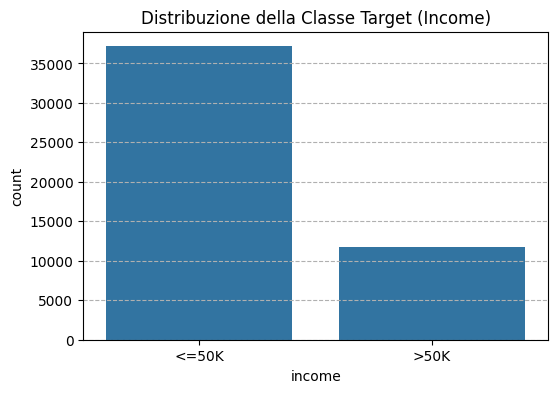

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(x='income', data=data)
plt.title('Distribuzione della Classe Target (Income)')
plt.grid(axis='y', linestyle='--')
plt.show()

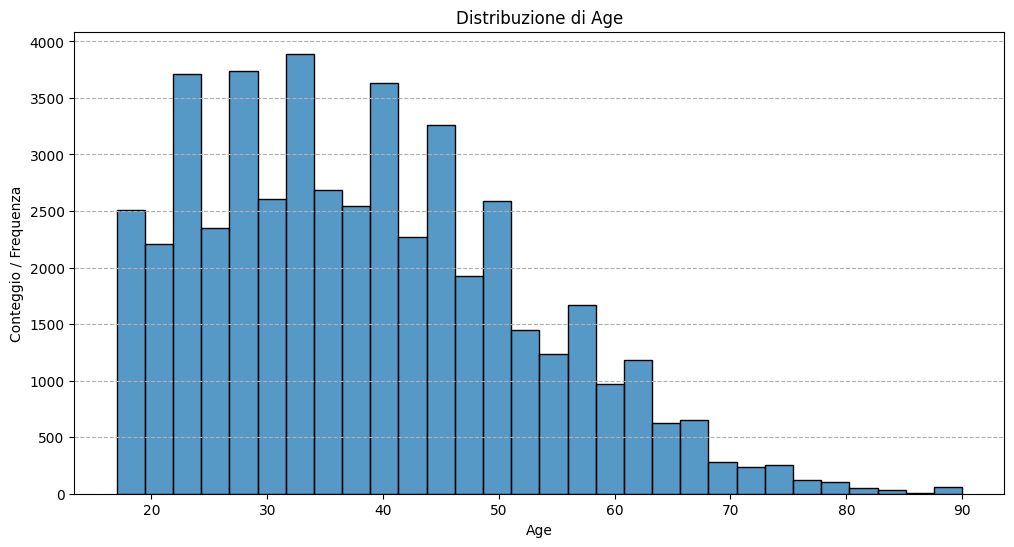

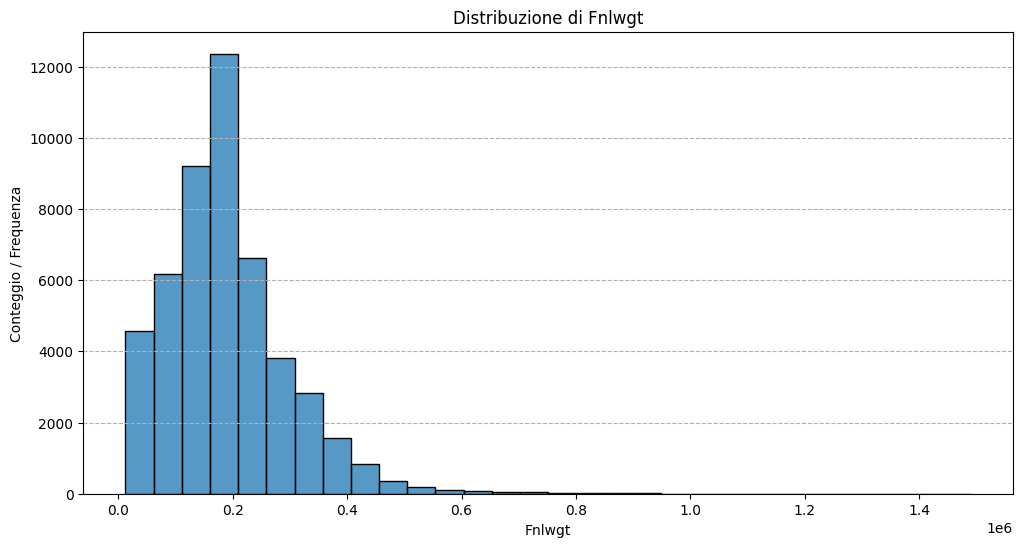

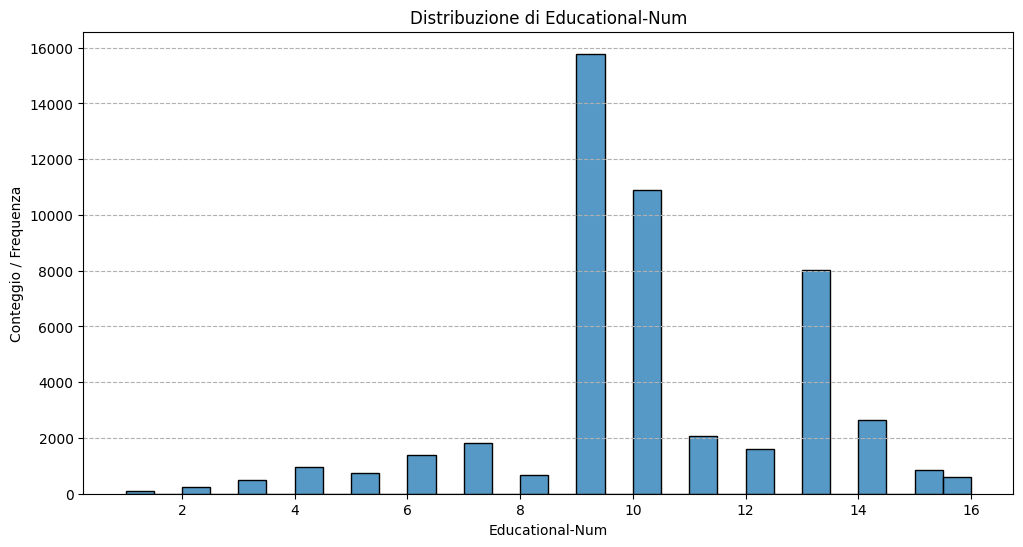

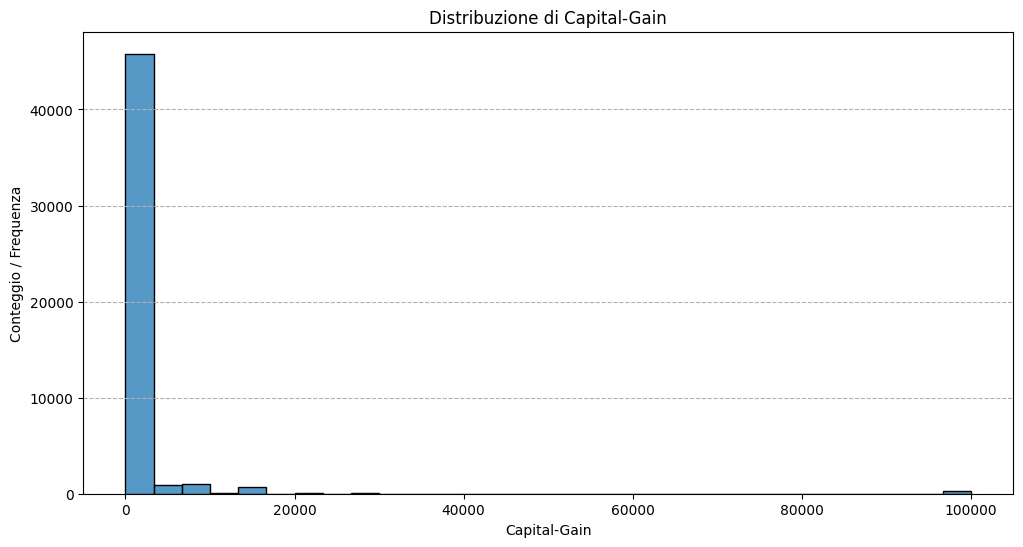

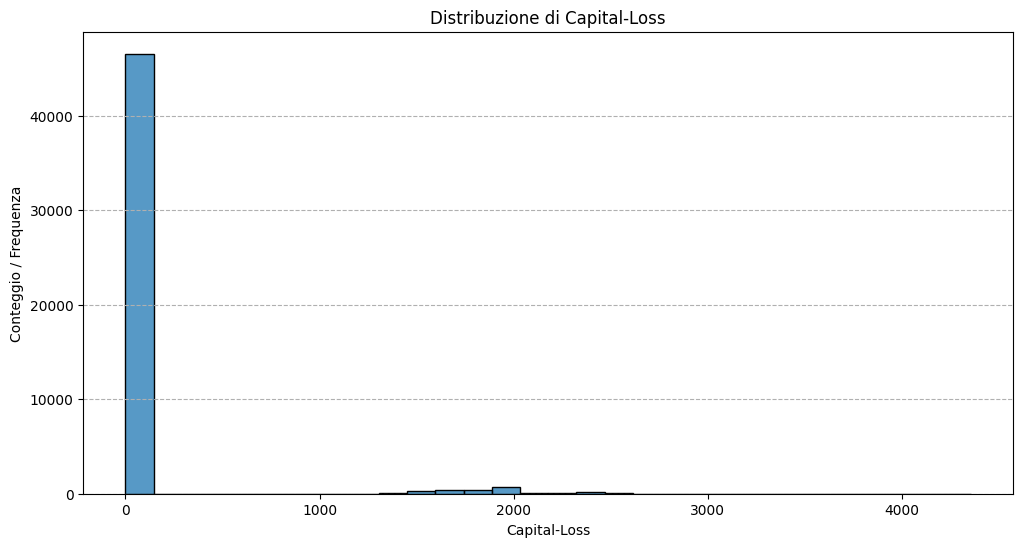

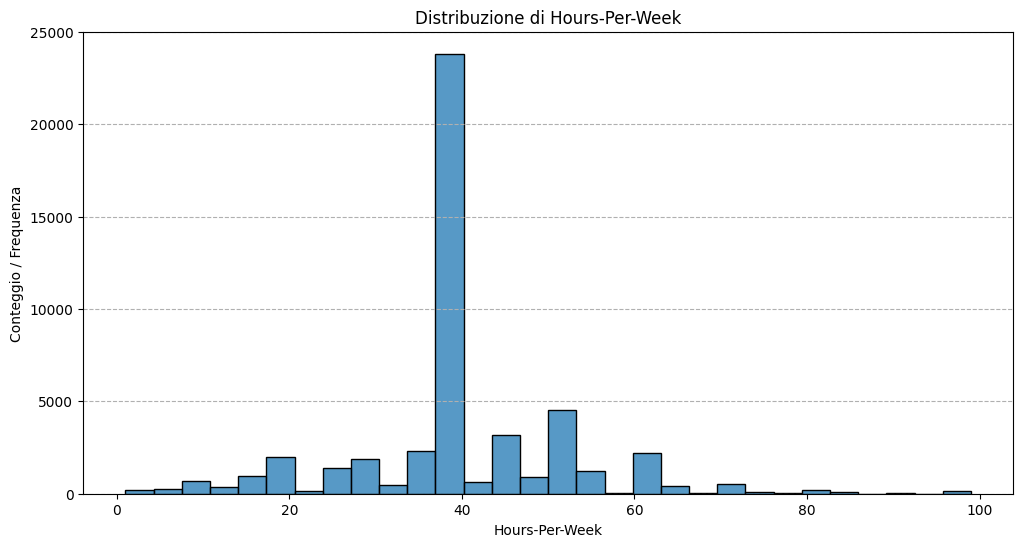

In [ ]:
numeric_vars = data.select_dtypes(include=['number']).columns

for col in numeric_vars:
    plt.figure(figsize=(12, 6))
    sns.histplot(data=data, x=col,bins = 30)
    plt.title(f'Distribuzione di {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Conteggio / Frequenza')
    plt.grid(axis='y', linestyle='--')
    plt.show()

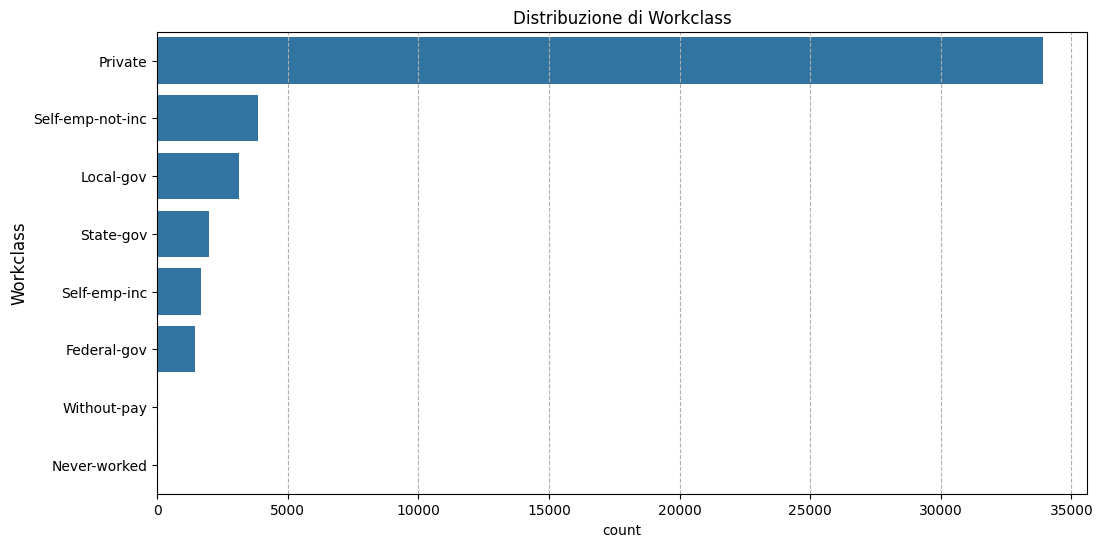

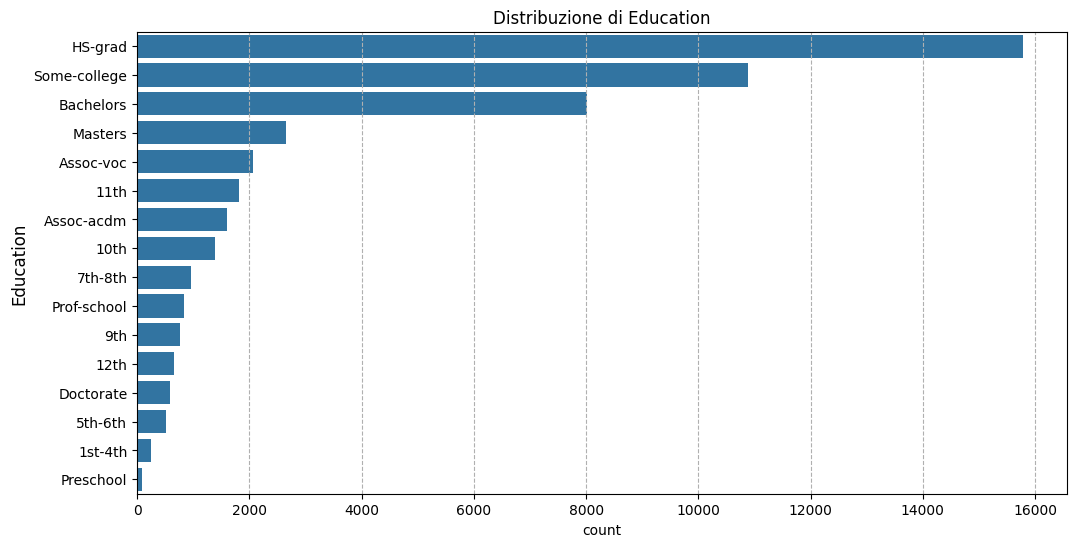

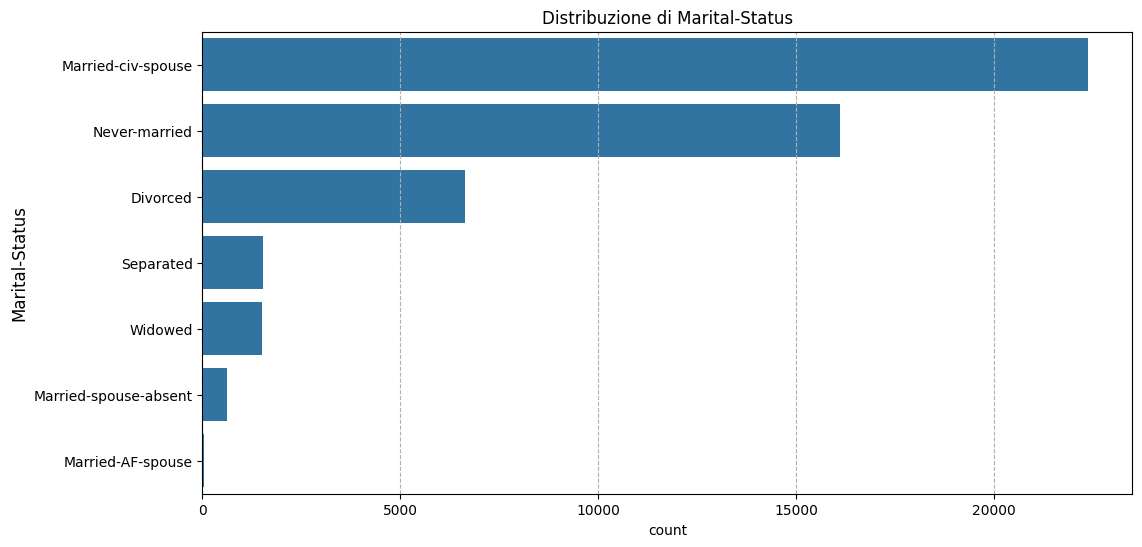

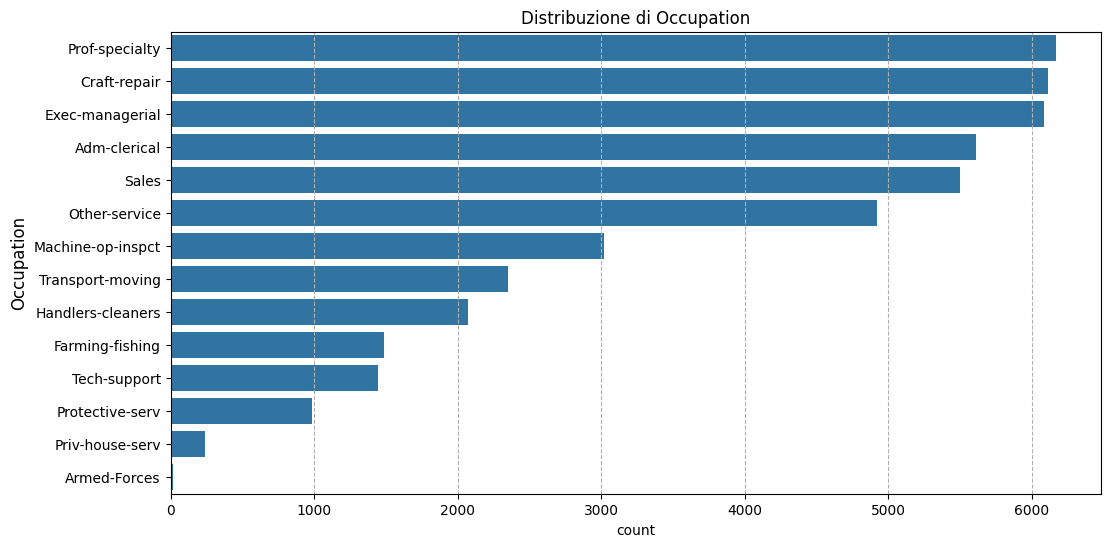

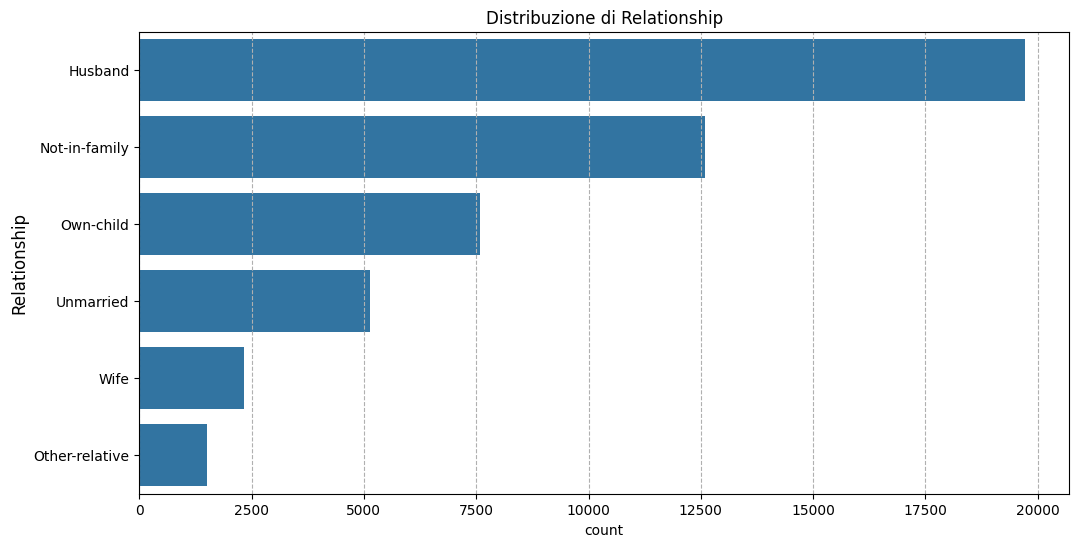

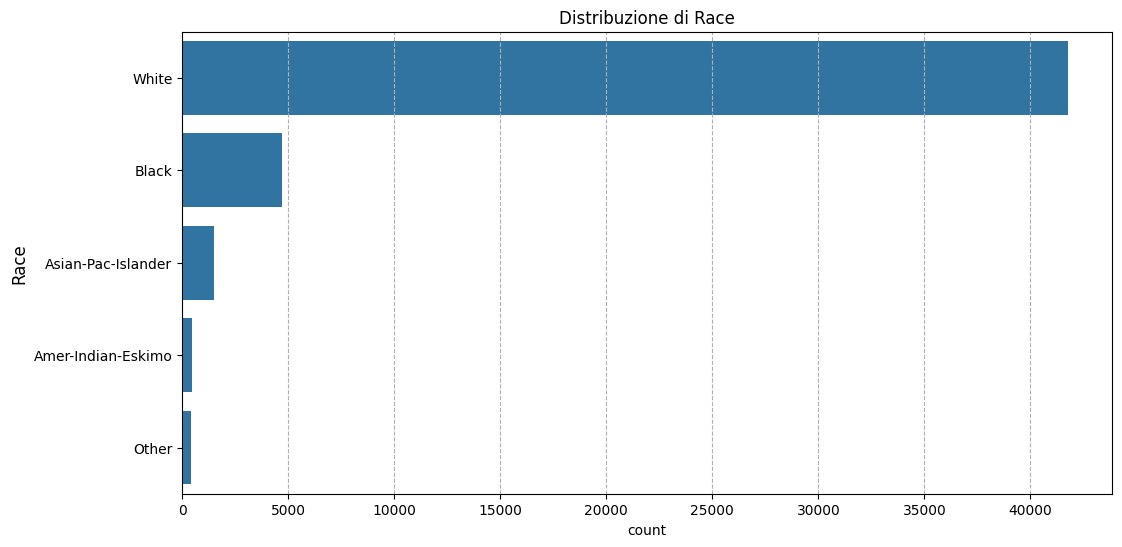

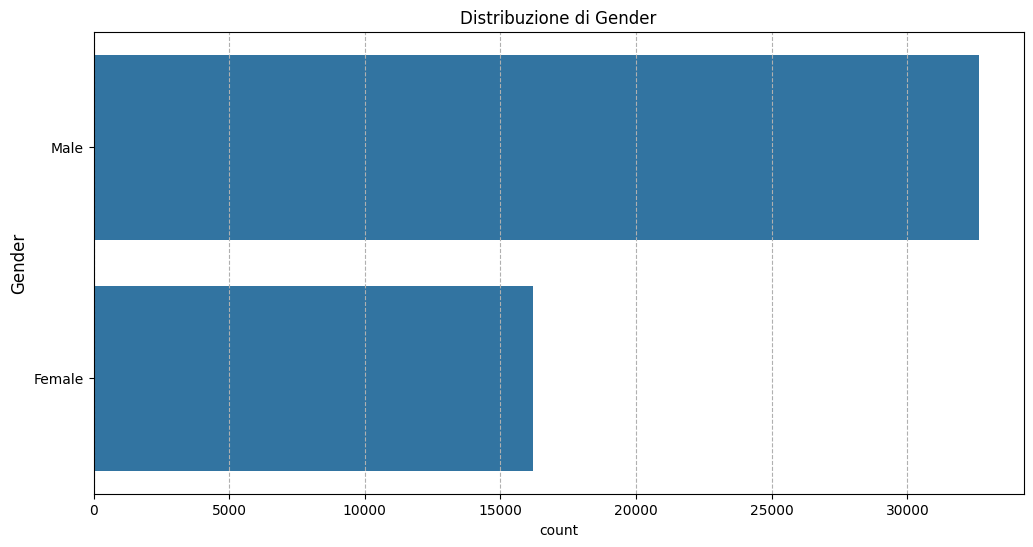

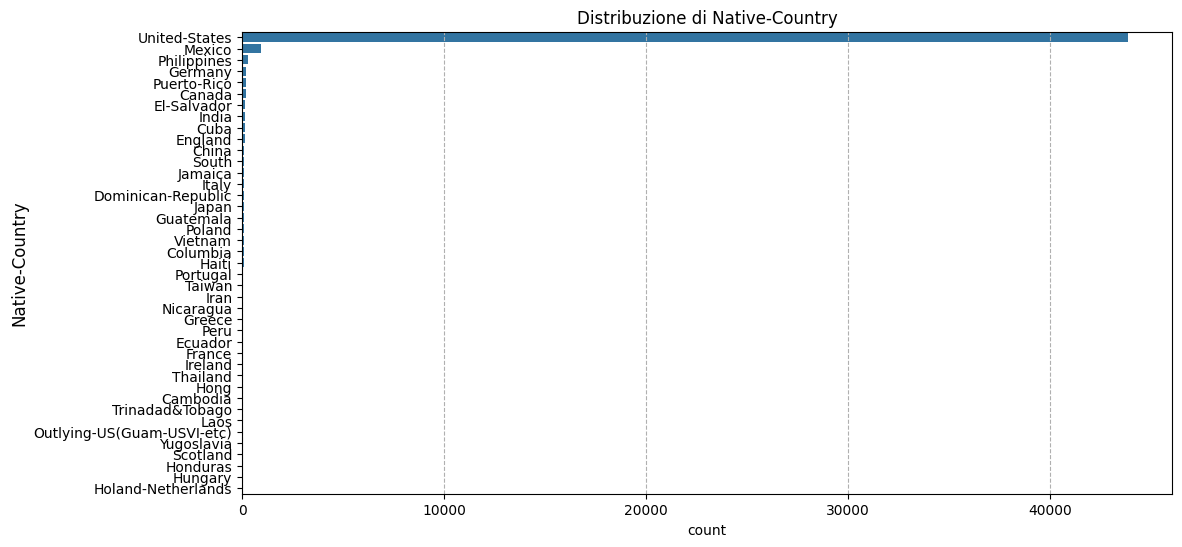

In [ ]:
categorical_vars = data.select_dtypes(include=['object']).columns
for col in categorical_vars:
    if col != 'income':
      plt.figure(figsize=(12, 6))
      sns.countplot(data=data, y=col, order=data[col].value_counts().index)
      plt.title(f'Distribuzione di {col.replace("_", " ").title()}')
      plt.ylabel(col.replace("_", " ").title(), fontsize=12)
      plt.grid(axis='x', linestyle='--')
      plt.show()


Text(0.5, 1.0, 'Matrice di correlazione tra feature numeriche')

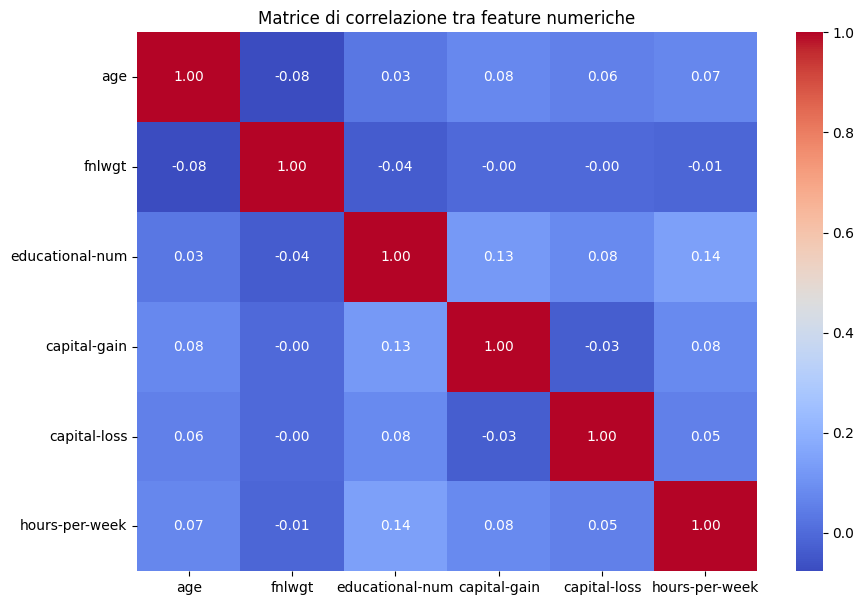

In [ ]:
correlation_matrix = data.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice di correlazione tra feature numeriche')

In [ ]:
print("\nMapping tra 'education' e 'educational-num':")
education_mapping = data[['education', 'educational-num']].drop_duplicates().sort_values('educational-num')
print(education_mapping.to_string())


Mapping tra 'education' e 'educational-num':
        education  educational-num
779     Preschool                1
323       1st-4th                2
37        5th-6th                3
9         7th-8th                4
54            9th                5
5            10th                6
0            11th                7
173          12th                8
1         HS-grad                9
3    Some-college               10
41      Assoc-voc               11
2      Assoc-acdm               12
11      Bachelors               13
15        Masters               14
7     Prof-school               15
19      Doctorate               16


# Preprocessing

In [ ]:
data_cleaned = data.dropna().copy()
data_cleaned.shape

(45222, 15)

In [ ]:
from sklearn.preprocessing import LabelEncoder

data_cleaned = data_cleaned.drop(['fnlwgt', 'education'], axis=1)

encoder = LabelEncoder()
data_cleaned['income'] = encoder.fit_transform(data_cleaned['income']).astype(int)

X = data_cleaned.drop('income', axis=1)
y = data_cleaned['income']

print("Prime 5 righe di X (features):")
display(X.head())

print("\nPrime 5 righe di y (target):")
display(y.head())

Prime 5 righe di X (features):


,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
5,34,Private,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States



Prime 5 righe di y (target):


,income
0,0
1,0
2,1
3,1
5,0


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector

numeric_features = make_column_selector(dtype_include=np.number)
categorical_features = make_column_selector(dtype_include=object)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"{len(X_train)} righe di training, {len(X_test)} righe di test.")


36177 righe di training, 9045 righe di test.


#Costruzione NN di base

In [ ]:
import tensorflow as tf
import keras
from keras.src.layers import Dense, Input
from keras.src.models import Sequential

se = 42
tf.random.set_seed(se)
np.random.seed(se)
tf.config.experimental.enable_op_determinism()


input_dim = X_train_processed.shape[1]
print('Input Shape =', input_dim)

model = Sequential()
model.add(Dense(128, activation='relu', input_dim=input_dim, kernel_initializer = keras.initializers.RandomNormal(seed=se)))
model.add(Dense(64, activation='relu', kernel_initializer = keras.initializers.RandomNormal(seed=se)))
model.add(Dense(32, activation='relu', kernel_initializer = keras.initializers.RandomNormal(seed=se)))
model.add(Dense(1, activation='sigmoid', kernel_initializer = keras.initializers.RandomNormal(seed=se)))

model.compile(
    loss='binary_crossentropy',
    optimizer= keras.optimizers.Adam(),
    metrics=['accuracy']
)

model.summary()

Input Shape = 87


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_103 (Dense)               │ (None, 128)            │        11,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_104 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_105 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_106 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,633 (84.50 KB)

 Trainable params: 21,633 (84.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import time
start = time.time()

history = model.fit(
    X_train_processed,
    y_train,
    epochs=50,
    validation_split=0.1
)
end = time.time()
print("Training time: ", end - start)

Epoch 1/50
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8245 - loss: 0.3864 - val_accuracy: 0.8513 - val_loss: 0.3219
Epoch 2/50
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8514 - loss: 0.3166 - val_accuracy: 0.8485 - val_loss: 0.3210
Epoch 3/50
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8543 - loss: 0.3129 - val_accuracy: 0.8491 - val_loss: 0.3208
Epoch 4/50
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8565 - loss: 0.3101 - val_accuracy: 0.8496 - val_loss: 0.3202
Epoch 5/50
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8584 - loss: 0.3076 - val_accuracy: 0.8488 - val_loss: 0.3198
Epoch 6/50
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8584 - loss: 0.3052 - val_accuracy: 0.8527 - val_loss: 0.3193
Epoch 7/50
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8603 - loss: 0.3035 - val_accuracy: 0.8538 - val_loss: 0.3193
Epoch 8/50
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8606 - loss: 0.3016 - 

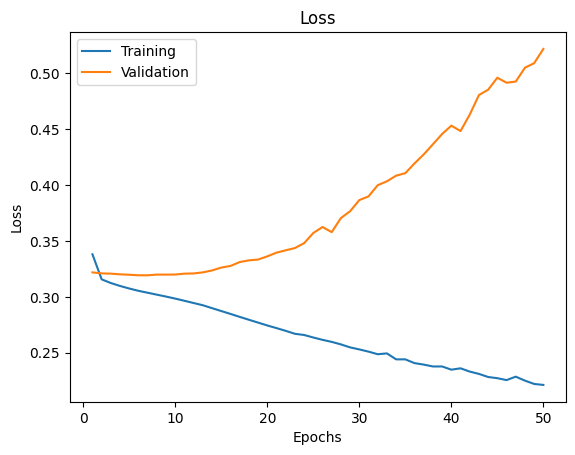

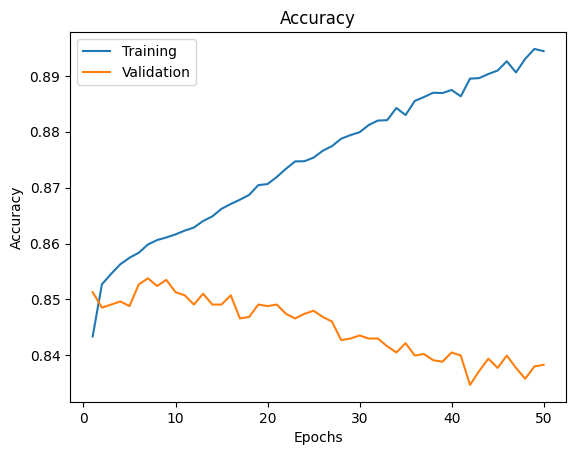

In [ ]:
import matplotlib.pyplot as plt

def plot_loss(history):
  x_plot = list(range(1,len(history.history["loss"])+1))
  plt.figure()
  plt.title("Loss")
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.plot(x_plot, history.history['loss'])
  plt.plot(x_plot, history.history['val_loss'])
  plt.legend(['Training', 'Validation'])

def plot_accuracy(history):
  x_plot = list(range(1,len(history.history["accuracy"])+1))
  plt.figure()
  plt.title("Accuracy")
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.plot(x_plot, history.history['accuracy'])
  plt.plot(x_plot, history.history['val_accuracy'])
  plt.legend(['Training', 'Validation'])

plot_loss(history)
plot_accuracy(history)

In [ ]:
loss, accuracy = model.evaluate(X_test_processed, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8309 - loss: 0.5514
Test Loss: 0.5504
Test Accuracy: 0.8306


283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


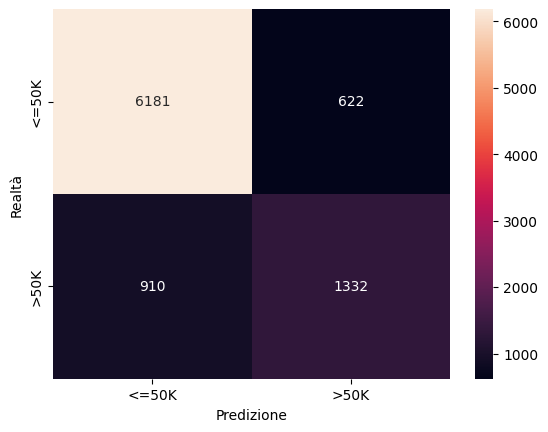

In [ ]:
from sklearn.metrics import confusion_matrix

prediction = model.predict(X_test_processed)
y_pred = (prediction > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
labels = ['<=50K', '>50K']
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predizione')
plt.ylabel('Realtà')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

              precision    recall  f1-score   support

       <=50K       0.87      0.91      0.89      6803
        >50K       0.68      0.59      0.63      2242

    accuracy                           0.83      9045
   macro avg       0.78      0.75      0.76      9045
weighted avg       0.82      0.83      0.83      9045



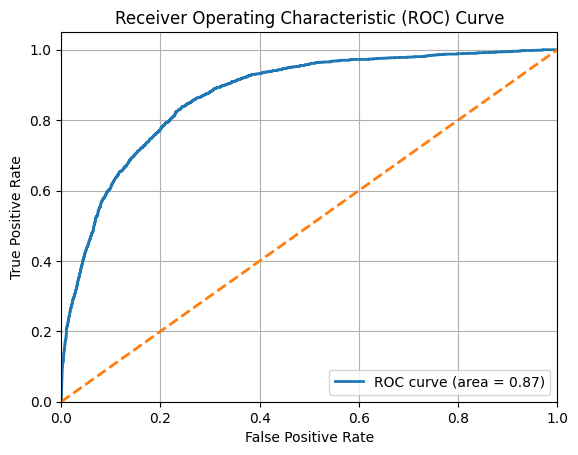

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, prediction)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

y_pred_series = pd.Series(y_pred.flatten(), index=y_test.index)

comparison_df = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred_series
})

false_positive_indices = comparison_df[
    (comparison_df['y_true'] == 0) & (comparison_df['y_pred'] == 1)
].index

false_negative_indices = comparison_df[
    (comparison_df['y_true'] == 1) & (comparison_df['y_pred'] == 0)
].index

def get_full_error_examples(indices, comparison_df):
    error_features = X_test.loc[indices]
    error_labels = comparison_df.loc[indices].copy()
    error_labels['Reale'] = encoder.inverse_transform(error_labels['y_true'])
    error_labels['Predetto'] = encoder.inverse_transform(error_labels['y_pred'])
    return error_features.join(error_labels[['Reale', 'Predetto']])

print(f"Falsi positivi ({len(false_positive_indices)})")
display(get_full_error_examples(false_positive_indices, comparison_df).head(5))

print(f"Falsi negativi ({len(false_negative_indices)})")
display(get_full_error_examples(false_negative_indices, comparison_df).head(5))


Falsi positivi (622)


,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,Reale,Predetto
22587,33,Private,9,Married-civ-spouse,Transport-moving,Husband,Black,Male,0,0,40,United-States,<=50K,>50K
205,34,Self-emp-inc,13,Married-civ-spouse,Sales,Husband,White,Male,0,0,54,United-States,<=50K,>50K
6389,53,Private,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K,>50K
25932,34,Private,13,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K,>50K
48290,43,Private,14,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,55,United-States,<=50K,>50K


Falsi negativi (910)


,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,Reale,Predetto
19345,41,Private,9,Married-spouse-absent,Prof-specialty,Not-in-family,Asian-Pac-Islander,Male,0,0,40,Japan,>50K,<=50K
45277,40,Federal-gov,9,Married-civ-spouse,Adm-clerical,Wife,White,Female,0,0,20,United-States,>50K,<=50K
19640,35,Private,14,Never-married,Exec-managerial,Not-in-family,White,Male,0,0,40,United-States,>50K,<=50K
2200,42,Private,3,Married-civ-spouse,Craft-repair,Husband,Other,Male,3103,0,40,Mexico,>50K,<=50K
42377,39,Private,13,Never-married,Exec-managerial,Not-in-family,White,Male,0,0,50,United-States,>50K,<=50K


#Costruzione NN migliorata

In [ ]:
from keras.src.layers import Dropout

se = 42
tf.random.set_seed(se)
np.random.seed(se)
tf.config.experimental.enable_op_determinism()

input_dim = X_train_processed.shape[1]
print(input_dim)

model2 = Sequential()

model2.add(Dense(32, activation='relu', input_dim=input_dim,
                 kernel_initializer = keras.initializers.RandomNormal(seed=se)))
model2.add(Dropout(0.3, seed = se))
model2.add(Dense(16, activation='relu',
                 kernel_initializer = keras.initializers.RandomNormal(seed=se)))
model2.add(Dropout(0.2, seed = se))
model2.add(Dense(1, activation='sigmoid',
                 kernel_initializer = keras.initializers.RandomNormal(seed=se)))

model2.compile(
    loss='binary_crossentropy',
    optimizer= keras.optimizers.Adam(learning_rate=0.0007),
    metrics=['accuracy']
)

model.summary()

87


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_103 (Dense)               │ (None, 128)            │        11,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_104 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_105 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_106 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,901 (253.52 KB)

 Trainable params: 21,633 (84.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 43,268 (169.02 KB)

In [ ]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start = time.time()

history = model2.fit(
    X_train_processed,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

end = time.time()
print("Training time: ", end - start)

Epoch 1/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7782 - loss: 0.5111 - val_accuracy: 0.8460 - val_loss: 0.3337
Epoch 2/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8423 - loss: 0.3374 - val_accuracy: 0.8521 - val_loss: 0.3256
Epoch 3/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8499 - loss: 0.3295 - val_accuracy: 0.8541 - val_loss: 0.3239
Epoch 4/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8496 - loss: 0.3249 - val_accuracy: 0.8502 - val_loss: 0.3231
Epoch 5/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8524 - loss: 0.3233 - val_accuracy: 0.8505 - val_loss: 0.3227
Epoch 6/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8531 - loss: 0.3217 - val_accuracy: 0.8519 - val_loss: 0.3223
Epoch 7/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8524 - loss: 0.3212 - val_accuracy: 0.8505 - val_loss: 0.3221
Epoch 8/30
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8537 - loss: 0.3211 - val_accuracy: 0.

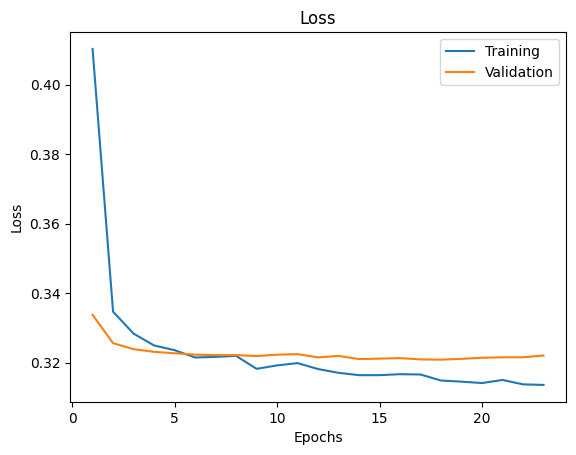

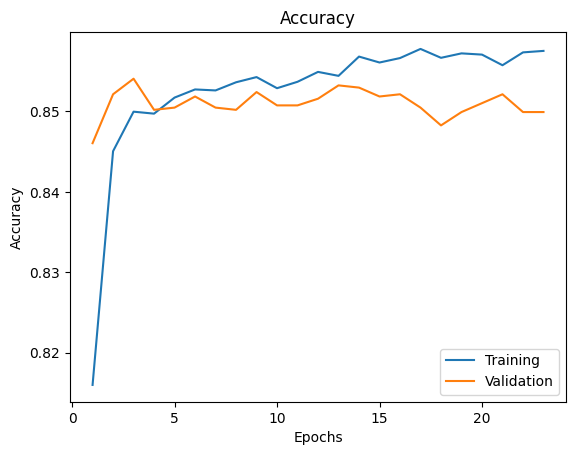

In [ ]:
import matplotlib.pyplot as plt

def plot_loss(history):
  x_plot = list(range(1,len(history.history["loss"])+1))
  plt.figure()
  plt.title("Loss")
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.plot(x_plot, history.history['loss'])
  plt.plot(x_plot, history.history['val_loss'])
  plt.legend(['Training', 'Validation'])

def plot_accuracy(history):
  x_plot = list(range(1,len(history.history["accuracy"])+1))
  plt.figure()
  plt.title("Accuracy")
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.plot(x_plot, history.history['accuracy'])
  plt.plot(x_plot, history.history['val_accuracy'])
  plt.legend(['Training', 'Validation'])

plot_loss(history)
plot_accuracy(history)

In [ ]:
loss2, accuracy2 = model2.evaluate(X_test_processed, y_test)
print(f"Test Loss: {loss2:.4f}")
print(f"Test Accuracy: {accuracy2:.4f}")

283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8521 - loss: 0.3193
Test Loss: 0.3172
Test Accuracy: 0.8511


283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


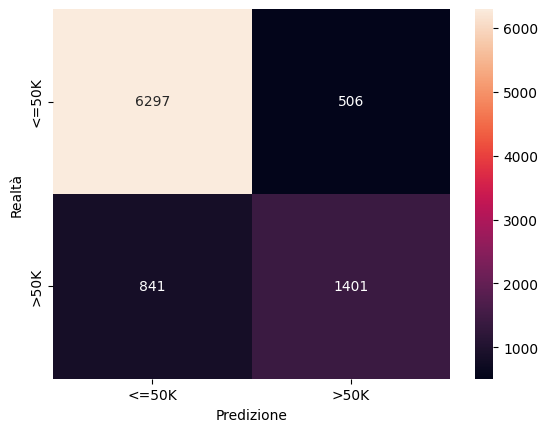

In [ ]:
prediction2 = model2.predict(X_test_processed)
y_pred2 = (prediction2 > 0.5).astype(int)

cm2 = confusion_matrix(y_test, y_pred2)
labels = ['<=50K', '>50K']
sns.heatmap(cm2, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predizione')
plt.ylabel('Realtà')
plt.show()

In [ ]:
print(classification_report(y_test, y_pred2, target_names=['<=50K', '>50K']))

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      6803
        >50K       0.73      0.62      0.68      2242

    accuracy                           0.85      9045
   macro avg       0.81      0.78      0.79      9045
weighted avg       0.85      0.85      0.85      9045



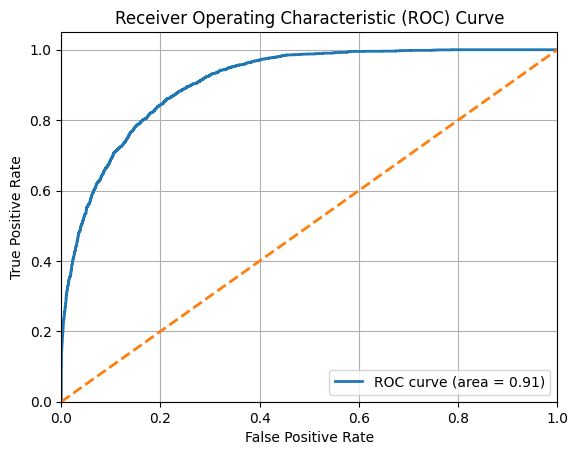

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, prediction2)
roc_auc2 = auc(fpr, tpr)

plt.plot(fpr, tpr, lw=2, label=f'ROC curve (area = {roc_auc2:.2f})')
plt.plot([0, 1], [0, 1], lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
y_pred_series2 = pd.Series(y_pred2.flatten(), index=y_test.index)

comparison_df2 = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred_series2
})

false_positive_indices2 = comparison_df2[
    (comparison_df2['y_true'] == 0) & (comparison_df2['y_pred'] == 1)
].index

false_negative_indices2 = comparison_df2[
    (comparison_df2['y_true'] == 1) & (comparison_df2['y_pred'] == 0)
].index

def get_full_error_examples(indices, comparison_df):
    error_features = X_test.loc[indices]
    error_labels = comparison_df.loc[indices].copy()
    error_labels['Reale'] = encoder.inverse_transform(error_labels['y_true'])
    error_labels['Predetto'] = encoder.inverse_transform(error_labels['y_pred'])
    return error_features.join(error_labels[['Reale', 'Predetto']])

print(f"Falsi positivi ({len(false_positive_indices2)})")
display(get_full_error_examples(false_positive_indices, comparison_df2).head(5))

print(f"Falsi negativi ({len(false_negative_indices2)})")
display(get_full_error_examples(false_negative_indices, comparison_df2).head(5))

Falsi positivi (506)


,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,Reale,Predetto
22587,33,Private,9,Married-civ-spouse,Transport-moving,Husband,Black,Male,0,0,40,United-States,<=50K,<=50K
205,34,Self-emp-inc,13,Married-civ-spouse,Sales,Husband,White,Male,0,0,54,United-States,<=50K,>50K
6389,53,Private,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K,<=50K
25932,34,Private,13,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K,>50K
48290,43,Private,14,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,55,United-States,<=50K,>50K


Falsi negativi (841)


,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,Reale,Predetto
19345,41,Private,9,Married-spouse-absent,Prof-specialty,Not-in-family,Asian-Pac-Islander,Male,0,0,40,Japan,>50K,<=50K
45277,40,Federal-gov,9,Married-civ-spouse,Adm-clerical,Wife,White,Female,0,0,20,United-States,>50K,<=50K
19640,35,Private,14,Never-married,Exec-managerial,Not-in-family,White,Male,0,0,40,United-States,>50K,<=50K
2200,42,Private,3,Married-civ-spouse,Craft-repair,Husband,Other,Male,3103,0,40,Mexico,>50K,<=50K
42377,39,Private,13,Never-married,Exec-managerial,Not-in-family,White,Male,0,0,50,United-States,>50K,<=50K
